# RTAB-Map Log Generation Notes

This notebook plots CSV files written by `loger.py`. For clean comparisons, remove the target CSV before each run so old samples are not appended.

All commands assume:

```bash
cd /home/oscar/robotino_ros2_ws
source install/setup.bash
```



## RGB-D + Lidar RTAB-Map Localization

Creates:

```text
/home/oscar/.ros/robotino_rtabmap_correction_log.csv
```

Launch:

```bash
rm -f ~/.ros/robotino_rtabmap_correction_log.csv
ros2 launch robotino_webots robotino_min_rtabmap_rgbd.launch.py \
  subscribe_scan:=true \
  subscribe_rgb:=true \
  subscribe_depth:=true \
  reg_strategy:=2 \
  grid_sensor:=2 \
  loger_csv_path:=~/.ros/robotino_rtabmap_correction_log.csv
```

This is the multimodal baseline: RTAB-Map uses RGB image, depth image, camera info, laser scan, and wheel odom.



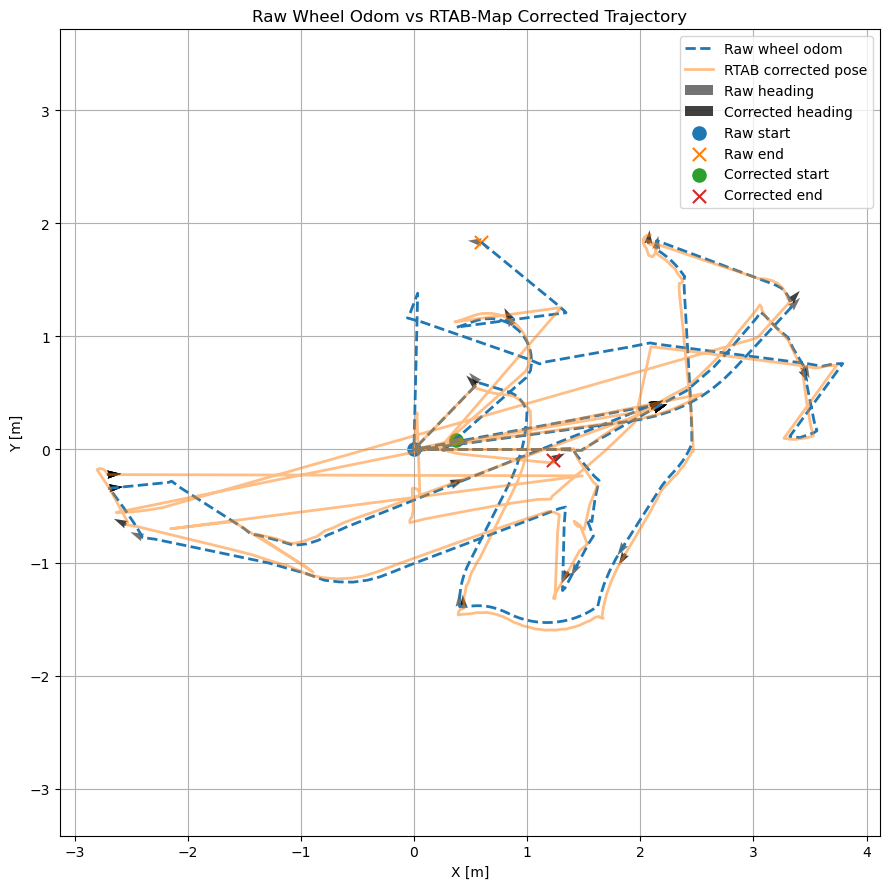

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

log_path = "/home/oscar/.ros/robotino_rtabmap_correction_log.csv"
#log_path ="/home/oscar/.ros/robotino_rtabmap_visual_only_correction_log.csv"

df = pd.read_csv(log_path)

# Optional: thin arrows so the plot stays readable
arrow_step = max(1, len(df) // 35)
arrow_len = 0.12

plt.figure(figsize=(9, 9))

# XY trajectories
plt.plot(
    df["odom_x"],
    df["odom_y"],
    label="Raw wheel odom",
    linestyle="dashed",
    linewidth=2,
)

plt.plot(
    df["map_base_x"],
    df["map_base_y"],
    label="RTAB corrected pose",
    linewidth=2,
    alpha=0.5,
)

# Heading arrows for raw odom
raw = df.iloc[::arrow_step]
plt.quiver(
    raw["odom_x"],
    raw["odom_y"],
    np.cos(raw["odom_yaw"]) * arrow_len,
    np.sin(raw["odom_yaw"]) * arrow_len,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    alpha=0.55,
    label="Raw heading",
)

# Heading arrows for corrected pose
corr = df.iloc[::arrow_step]
plt.quiver(
    corr["map_base_x"],
    corr["map_base_y"],
    np.cos(corr["map_base_yaw"]) * arrow_len,
    np.sin(corr["map_base_yaw"]) * arrow_len,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    alpha=0.75,
    label="Corrected heading",
)

# Start/end markers
plt.scatter(df["odom_x"].iloc[0], df["odom_y"].iloc[0], marker="o", s=90, label="Raw start")
plt.scatter(df["odom_x"].iloc[-1], df["odom_y"].iloc[-1], marker="x", s=90, label="Raw end")

plt.scatter(df["map_base_x"].iloc[0], df["map_base_y"].iloc[0], marker="o", s=90, label="Corrected start")
plt.scatter(df["map_base_x"].iloc[-1], df["map_base_y"].iloc[-1], marker="x", s=90, label="Corrected end")

plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Raw Wheel Odom vs RTAB-Map Corrected Trajectory")
plt.axis("equal")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

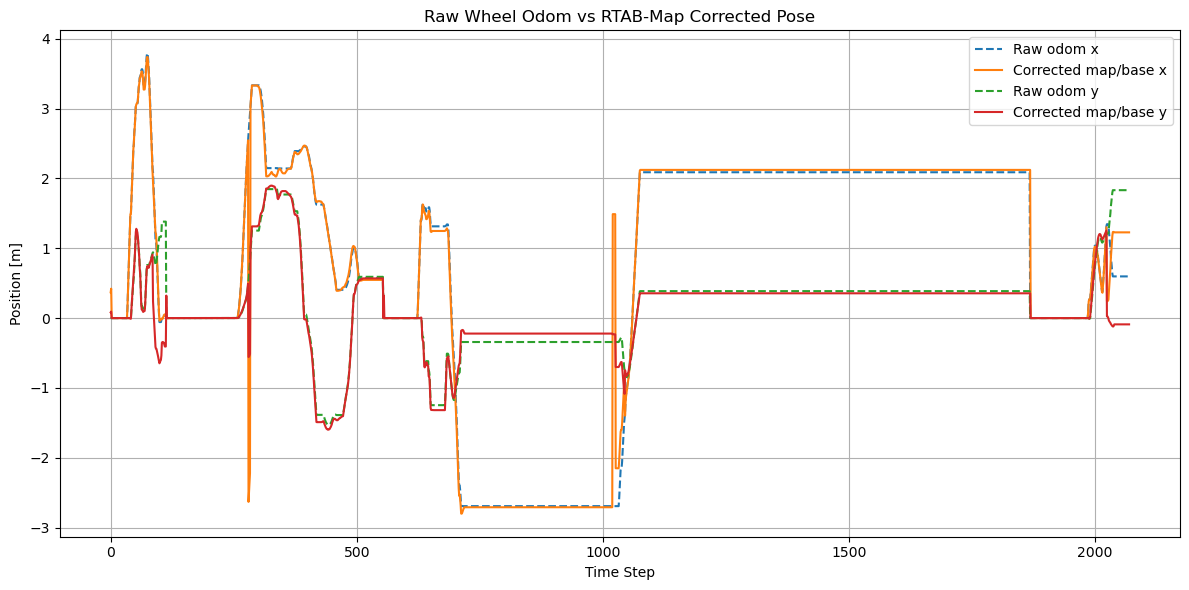

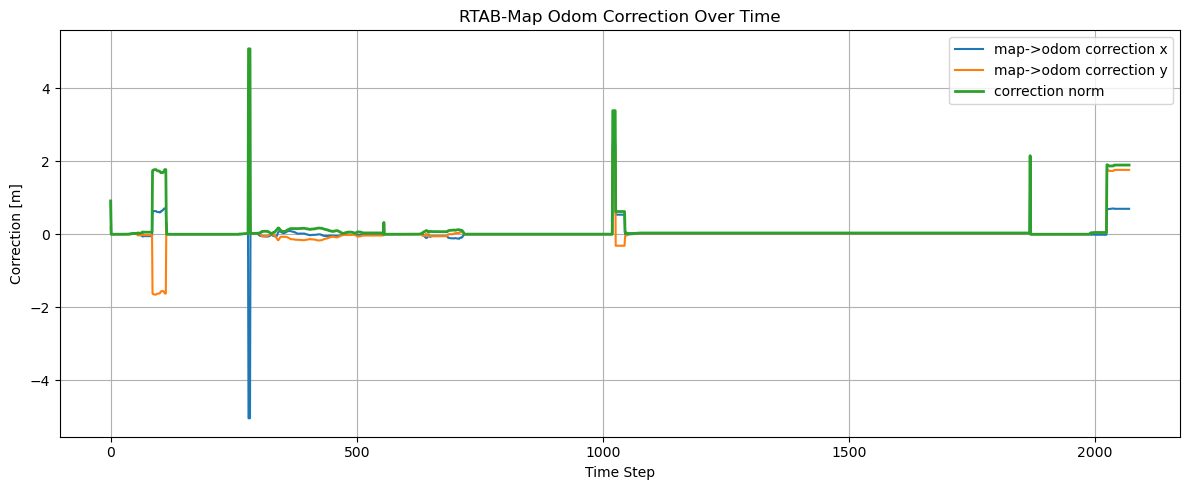

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


# Use sample index as time if you only care about sequence
df["time"] = range(len(df))

plt.figure(figsize=(12, 6))

plt.plot(df["time"], df["odom_x"], label="Raw odom x", linestyle="dashed")
plt.plot(df["time"], df["map_base_x"], label="Corrected map/base x")

plt.plot(df["time"], df["odom_y"], label="Raw odom y", linestyle="dashed")
plt.plot(df["time"], df["map_base_y"], label="Corrected map/base y")

plt.xlabel("Time Step")
plt.ylabel("Position [m]")
plt.title("Raw Wheel Odom vs RTAB-Map Corrected Pose")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Plot the actual RTAB correction: map -> odom
plt.figure(figsize=(12, 5))

plt.plot(df["time"], df["map_odom_x"], label="map->odom correction x")
plt.plot(df["time"], df["map_odom_y"], label="map->odom correction y")
plt.plot(df["time"], df["correction_norm"], label="correction norm", linewidth=2)

plt.xlabel("Time Step")
plt.ylabel("Correction [m]")
plt.title("RTAB-Map Odom Correction Over Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Visual RGB-D Only RTAB-Map Localization

Creates:

```text
/home/oscar/.ros/robotino_rtabmap_visual_only_correction_log.csv
```

Launch:

```bash
rm -f ~/.ros/robotino_rtabmap_visual_only_correction_log.csv
ros2 launch robotino_webots robotino_min_rtabmap_rgbd.launch.py \
  subscribe_scan:=false \
  subscribe_rgb:=true \
  subscribe_depth:=true \
  reg_strategy:=0 \
  grid_sensor:=1 \
  loger_csv_path:=~/.ros/robotino_rtabmap_visual_only_correction_log.csv
```

This tests whether the saved RTAB-Map database can localize from RGB-D visual features without live lidar.



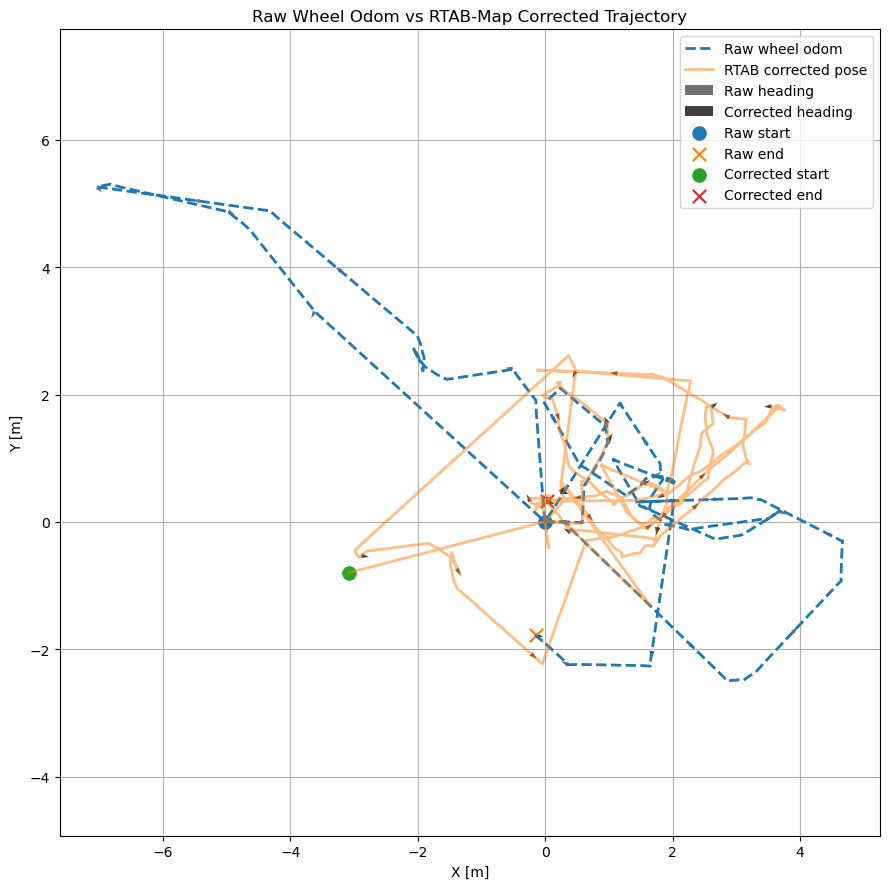

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#log_path = "/home/oscar/.ros/robotino_rtabmap_correction_log.csv"
log_path ="/home/oscar/.ros/robotino_rtabmap_visual_only_correction_log.csv"
df = pd.read_csv(log_path)
#df_whole = pd.read_csv(log_path)
#df= df_whole.iloc[-50:]
# Optional: thin arrows so the plot stays readable
arrow_step = max(1, len(df) // 35)
arrow_len = 0.12

plt.figure(figsize=(9, 9))

# XY trajectories
plt.plot(
    df["odom_x"],
    df["odom_y"],
    label="Raw wheel odom",
    linestyle="dashed",
    linewidth=2,
)

plt.plot(
    df["map_base_x"],
    df["map_base_y"],
    label="RTAB corrected pose",
    linewidth=2,
    alpha=0.5,
)

# Heading arrows for raw odom
raw = df.iloc[::arrow_step]
plt.quiver(
    raw["odom_x"],
    raw["odom_y"],
    np.cos(raw["odom_yaw"]) * arrow_len,
    np.sin(raw["odom_yaw"]) * arrow_len,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    alpha=0.55,
    label="Raw heading",
)

# Heading arrows for corrected pose
corr = df.iloc[::arrow_step]
plt.quiver(
    corr["map_base_x"],
    corr["map_base_y"],
    np.cos(corr["map_base_yaw"]) * arrow_len,
    np.sin(corr["map_base_yaw"]) * arrow_len,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    alpha=0.75,
    label="Corrected heading",
)

# Start/end markers
plt.scatter(df["odom_x"].iloc[0], df["odom_y"].iloc[0], marker="o", s=90, label="Raw start")
plt.scatter(df["odom_x"].iloc[-1], df["odom_y"].iloc[-1], marker="x", s=90, label="Raw end")

plt.scatter(df["map_base_x"].iloc[0], df["map_base_y"].iloc[0], marker="o", s=90, label="Corrected start")
plt.scatter(df["map_base_x"].iloc[-1], df["map_base_y"].iloc[-1], marker="x", s=90, label="Corrected end")

plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Raw Wheel Odom vs RTAB-Map Corrected Trajectory")
plt.axis("equal")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

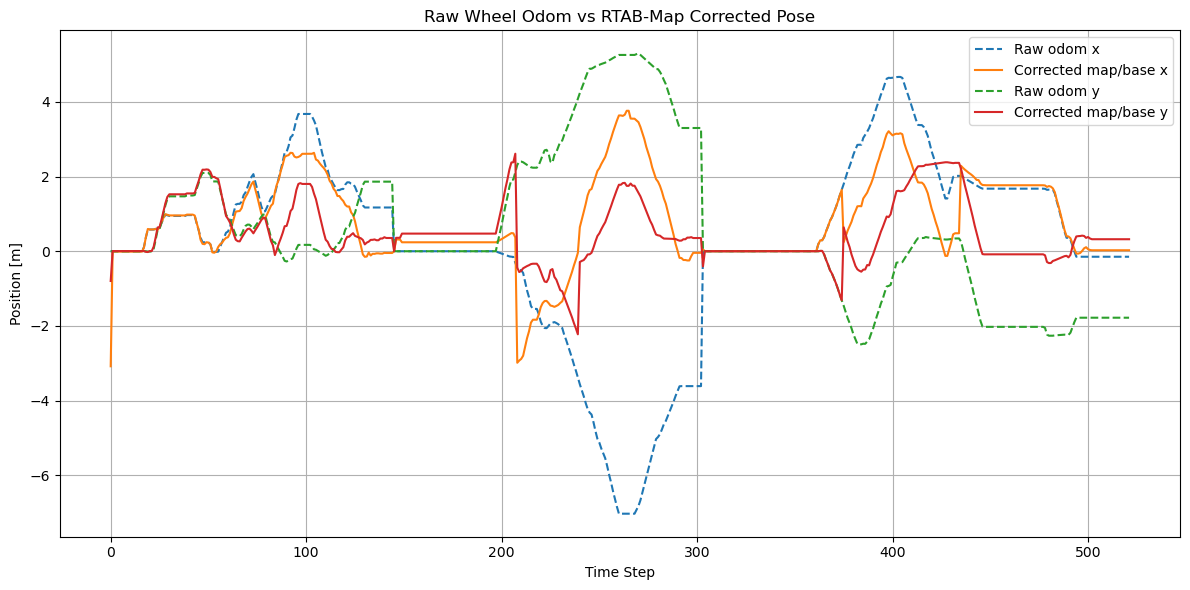

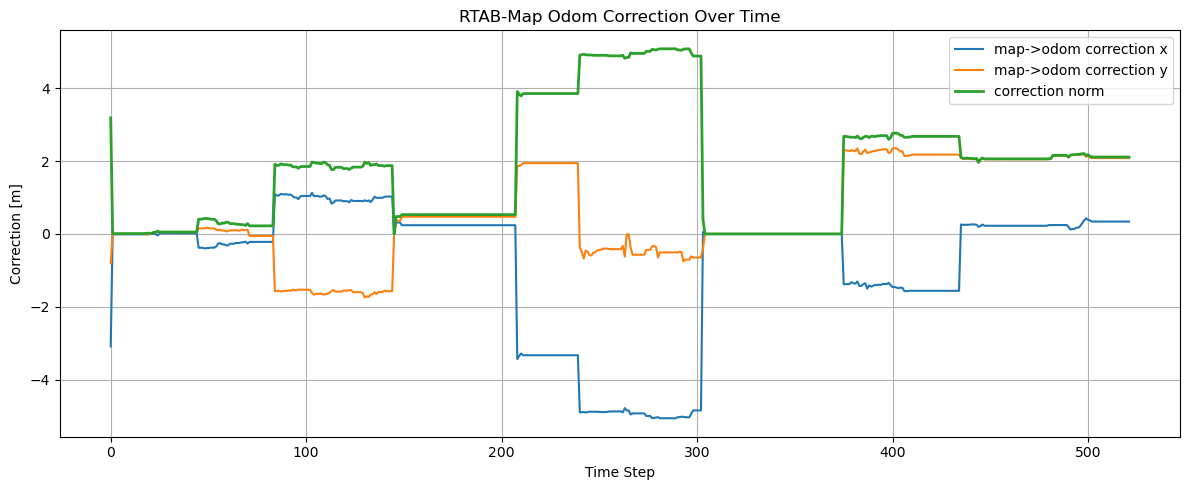

In [8]:

# Use sample index as time if you only care about sequence
df["time"] = range(len(df))

plt.figure(figsize=(12, 6))

plt.plot(df["time"], df["odom_x"], label="Raw odom x", linestyle="dashed")
plt.plot(df["time"], df["map_base_x"], label="Corrected map/base x")

plt.plot(df["time"], df["odom_y"], label="Raw odom y", linestyle="dashed")
plt.plot(df["time"], df["map_base_y"], label="Corrected map/base y")

plt.xlabel("Time Step")
plt.ylabel("Position [m]")
plt.title("Raw Wheel Odom vs RTAB-Map Corrected Pose")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Plot the actual RTAB correction: map -> odom
plt.figure(figsize=(12, 5))

plt.plot(df["time"], df["map_odom_x"], label="map->odom correction x")
plt.plot(df["time"], df["map_odom_y"], label="map->odom correction y")
plt.plot(df["time"], df["correction_norm"], label="correction norm", linewidth=2)

plt.xlabel("Time Step")
plt.ylabel("Correction [m]")
plt.title("RTAB-Map Odom Correction Over Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Laser Scan Only RTAB-Map Localization

Creates:

```text
/home/oscar/.ros/robotino_rtabmap_scan_only_correction_log.csv
```

Launch:

```bash
rm -f ~/.ros/robotino_rtabmap_scan_only_correction_log.csv
ros2 launch robotino_webots robotino_min_rtabmap_rgbd.launch.py \
  subscribe_scan:=true \
  subscribe_rgb:=false \
  subscribe_depth:=false \
  reg_strategy:=1 \
  grid_sensor:=0 \
  loger_csv_path:=~/.ros/robotino_rtabmap_scan_only_correction_log.csv
```

This is a scan-only RTAB-Map check. It is not AMCL: it uses RTAB-Map's localization pipeline and may not behave like particle-filter localization over a 2D occupancy map.



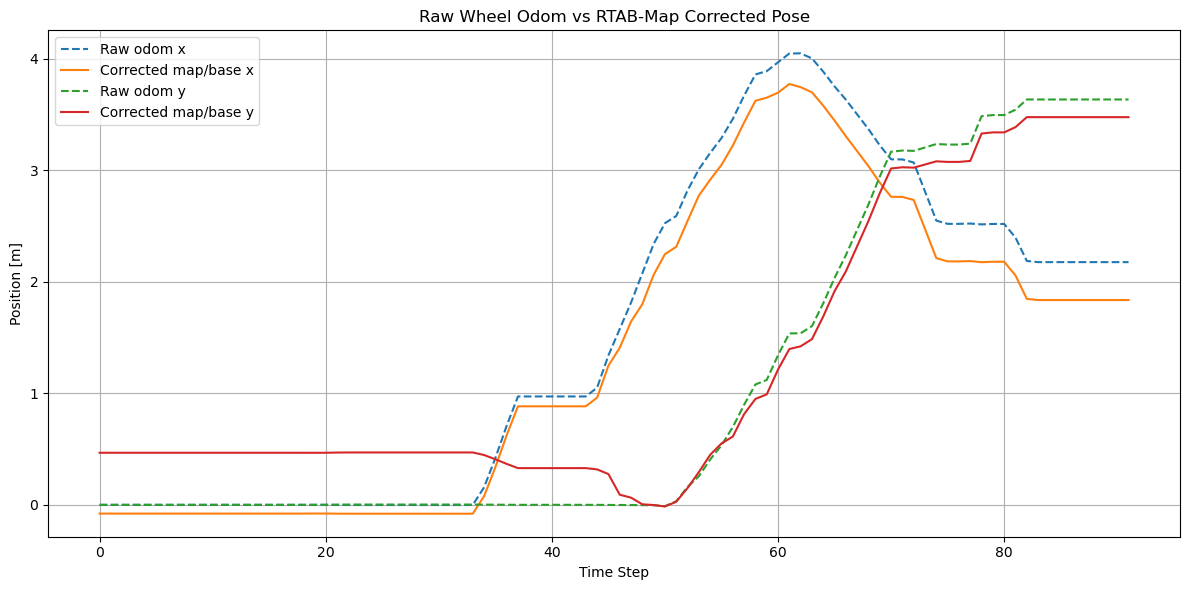

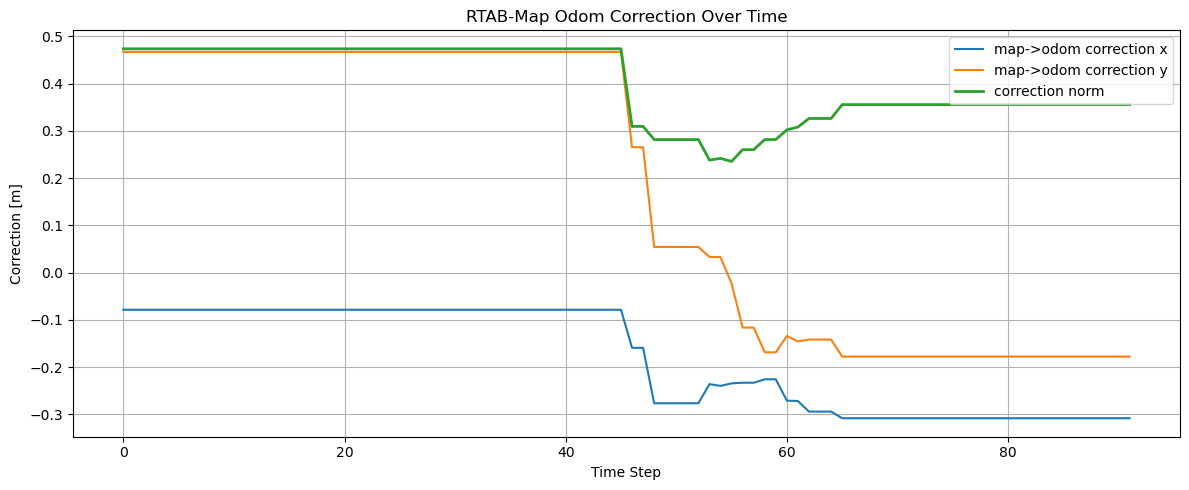

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

#log_path = "/home/oscar/.ros/robotino_rtabmap_correction_log.csv"
log_path ="/home/oscar/.ros/robotino_rtabmap_scan_only_correction_log.csv"


df = pd.read_csv(log_path)

# Use sample index as time if you only care about sequence
df["time"] = range(len(df))

plt.figure(figsize=(12, 6))

plt.plot(df["time"], df["odom_x"], label="Raw odom x", linestyle="dashed")
plt.plot(df["time"], df["map_base_x"], label="Corrected map/base x")

plt.plot(df["time"], df["odom_y"], label="Raw odom y", linestyle="dashed")
plt.plot(df["time"], df["map_base_y"], label="Corrected map/base y")

plt.xlabel("Time Step")
plt.ylabel("Position [m]")
plt.title("Raw Wheel Odom vs RTAB-Map Corrected Pose")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Plot the actual RTAB correction: map -> odom
plt.figure(figsize=(12, 5))

plt.plot(df["time"], df["map_odom_x"], label="map->odom correction x")
plt.plot(df["time"], df["map_odom_y"], label="map->odom correction y")
plt.plot(df["time"], df["correction_norm"], label="correction norm", linewidth=2)

plt.xlabel("Time Step")
plt.ylabel("Correction [m]")
plt.title("RTAB-Map Odom Correction Over Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

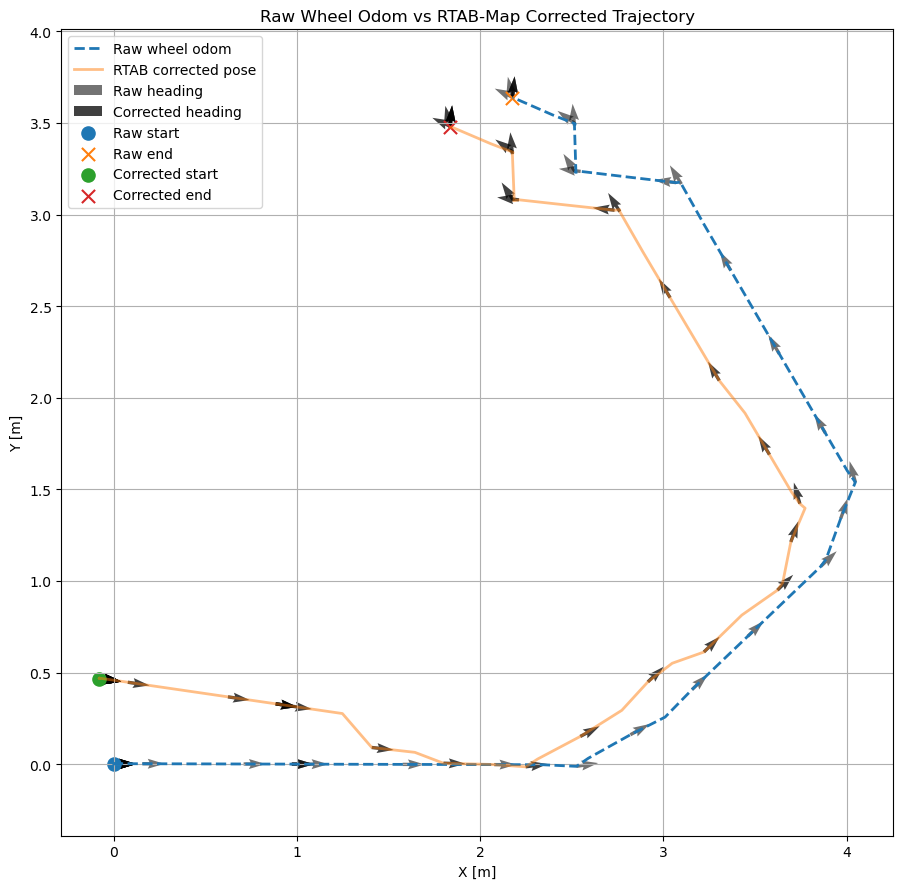

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Optional: thin arrows so the plot stays readable
arrow_step = max(1, len(df) // 35)
arrow_len = 0.12

plt.figure(figsize=(9, 9))

# XY trajectories
plt.plot(
    df["odom_x"],
    df["odom_y"],
    label="Raw wheel odom",
    linestyle="dashed",
    linewidth=2,
)

plt.plot(
    df["map_base_x"],
    df["map_base_y"],
    label="RTAB corrected pose",
    linewidth=2,
    alpha=0.5,
)

# Heading arrows for raw odom
raw = df.iloc[::arrow_step]
plt.quiver(
    raw["odom_x"],
    raw["odom_y"],
    np.cos(raw["odom_yaw"]) * arrow_len,
    np.sin(raw["odom_yaw"]) * arrow_len,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    alpha=0.55,
    label="Raw heading",
)

# Heading arrows for corrected pose
corr = df.iloc[::arrow_step]
plt.quiver(
    corr["map_base_x"],
    corr["map_base_y"],
    np.cos(corr["map_base_yaw"]) * arrow_len,
    np.sin(corr["map_base_yaw"]) * arrow_len,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    alpha=0.75,
    label="Corrected heading",
)

# Start/end markers
plt.scatter(df["odom_x"].iloc[0], df["odom_y"].iloc[0], marker="o", s=90, label="Raw start")
plt.scatter(df["odom_x"].iloc[-1], df["odom_y"].iloc[-1], marker="x", s=90, label="Raw end")

plt.scatter(df["map_base_x"].iloc[0], df["map_base_y"].iloc[0], marker="o", s=90, label="Corrected start")
plt.scatter(df["map_base_x"].iloc[-1], df["map_base_y"].iloc[-1], marker="x", s=90, label="Corrected end")

plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Raw Wheel Odom vs RTAB-Map Corrected Trajectory")
plt.axis("equal")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## GRAPH NAVIGATION



Call set goal service:

```bash
ros2 service call /rtabmap/set_goal rtabmap_msgs/srv/SetGoal \
"{node_id: 42, node_label: '', frame_id: ''}"
requester: making request: rtabmap_msgs.srv.SetGoal_Request(node_id=42, node_label='', frame_id='')

```

